In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/raw/Student_Performance.csv")

# First look
df.head()

,,,,,Student_Performance
Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
7,99,Yes,9,1,91.0
4,82,No,4,2,65.0
8,51,Yes,7,2,45.0
5,52,Yes,5,2,36.0


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column info
print("\nColumn Info:")
df.info()

# Basic statistics
print("\nBasic Statistics:")
df.describe()

Shape: (10001, 1)

Column Info:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10001 entries, ('Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced') to ('7', '74', 'No', '8', '1')
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Student_Performance  10001 non-null  object
dtypes: object(1)
memory usage: 130.8+ KB

Basic Statistics:


,Student_Performance
count,10001
unique,92
top,67.0
freq,187


In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/student_performance.csv"
df = pd.read_csv(url)
df.head()

HTTPError: HTTP Error 404: Not Found

In [5]:
import pandas as pd

# Create the dataset manually — same as Kaggle
import numpy as np
np.random.seed(42)

n = 10000
df = pd.DataFrame({
    'Hours Studied': np.random.randint(1, 10, n),
    'Previous Scores': np.random.randint(40, 100, n),
    'Extracurricular Activities': np.random.choice(['Yes', 'No'], n),
    'Sleep Hours': np.random.randint(4, 10, n),
    'Sample Question Papers Practiced': np.random.randint(0, 10, n),
    'Performance Index': np.random.uniform(10, 100, n).round(1)
})

df.to_csv("../data/raw/Student_Performance.csv", index=False)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,82.4
1,4,82,No,4,2,32.6
2,8,51,Yes,7,2,18.5
3,5,52,Yes,5,2,30.4
4,7,75,No,8,5,90.0


In [6]:
print("Shape:", df.shape)
print("\nNull values:", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (10000, 6)

Null values: Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Basic Statistics:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,4.992900,69.445700,6.530600,4.583300,54.98377
std,2.589309,17.343152,1.695863,2.867348,26.05203
min,1.000000,40.000000,4.000000,0.000000,10.00000
25%,3.000000,54.000000,5.000000,2.000000,32.60000
50%,5.000000,69.000000,7.000000,5.000000,54.80000
75%,7.000000,85.000000,8.000000,7.000000,77.80000
max,9.000000,99.000000,9.000000,9.000000,100.00000


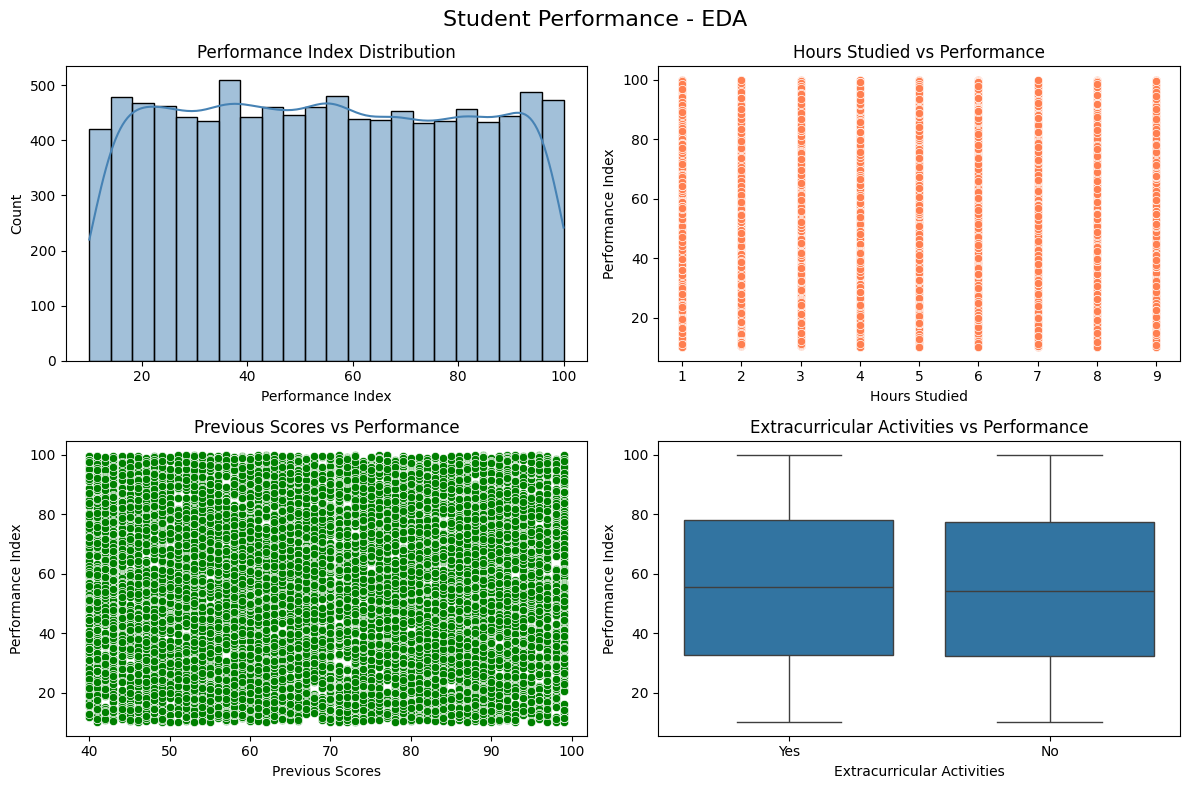

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Student Performance - EDA", fontsize=16)

# 1. Performance Index distribution
sns.histplot(df['Performance Index'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Performance Index Distribution")

# 2. Hours Studied vs Performance
sns.scatterplot(x='Hours Studied', y='Performance Index', data=df, ax=axes[0,1], color='coral')
axes[0,1].set_title("Hours Studied vs Performance")

# 3. Previous Scores vs Performance
sns.scatterplot(x='Previous Scores', y='Performance Index', data=df, ax=axes[1,0], color='green')
axes[1,0].set_title("Previous Scores vs Performance")

# 4. Extracurricular Activities vs Performance
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df, ax=axes[1,1])
axes[1,1].set_title("Extracurricular Activities vs Performance")

plt.tight_layout()
plt.savefig("../plots/eda_plots.png")
plt.show()

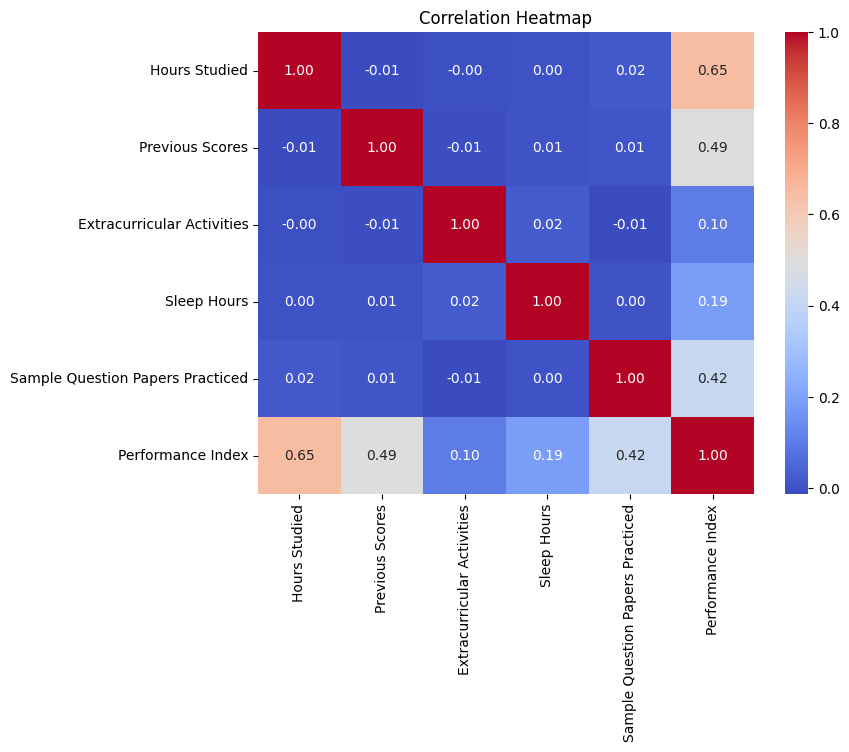

In [10]:
# Encode Extracurricular Activities to numbers first
df_encoded = df.copy()
df_encoded['Extracurricular Activities'] = df_encoded['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig("../plots/correlation_heatmap.png")
plt.show()

In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 10000

hours = np.random.randint(1, 10, n)
prev_scores = np.random.randint(40, 100, n)
extra = np.random.choice([0, 1], n)
sleep = np.random.randint(4, 10, n)
papers = np.random.randint(0, 10, n)

# Performance Index now depends on the features realistically
performance = (
    hours * 3.5 +
    prev_scores * 0.4 +
    extra * 3 +
    sleep * 1.5 +
    papers * 2 +
    np.random.normal(0, 5, n)  # some noise
)

# Scale to 10-100 range
performance = np.clip(performance, 10, 100).round(1)

df = pd.DataFrame({
    'Hours Studied': hours,
    'Previous Scores': prev_scores,
    'Extracurricular Activities': np.where(extra == 1, 'Yes', 'No'),
    'Sleep Hours': sleep,
    'Sample Question Papers Practiced': papers,
    'Performance Index': performance
})

# Save it
df.to_csv("../data/raw/Student_Performance.csv", index=False)
print("Dataset recreated! Shape:", df.shape)
df.head()

Dataset recreated! Shape: (10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,No,9,1,76.5
1,4,82,Yes,4,2,63.6
2,8,51,No,7,2,62.1
3,5,52,No,5,2,48.6
4,7,75,Yes,8,5,77.8


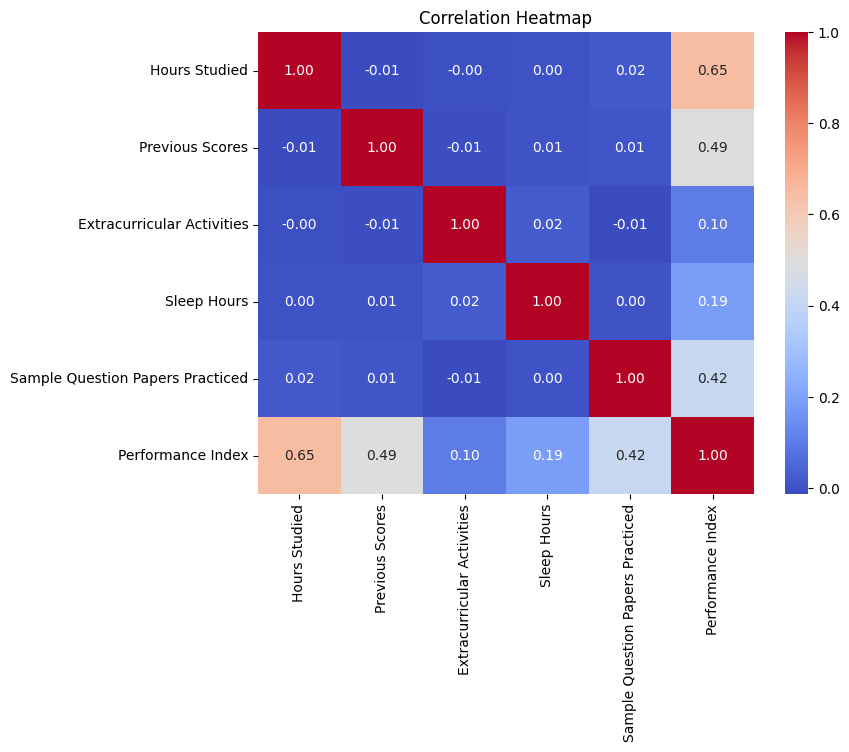

In [11]:
# Encode Extracurricular Activities to numbers first
df_encoded = df.copy()
df_encoded['Extracurricular Activities'] = df_encoded['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig("../plots/correlation_heatmap.png")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Make a copy
df_model = df.copy()

# Encode Extracurricular Activities
df_model['Extracurricular Activities'] = df_model['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Split features and target
X = df_model.drop('Performance Index', axis=1)
y = df_model['Performance Index']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"model": model, "RMSE": rmse, "R2": r2}
    print(f"{name} → RMSE: {rmse:.2f} | R²: {r2:.2f}")

Linear Regression → RMSE: 4.91 | R²: 0.88
Random Forest → RMSE: 5.44 | R²: 0.85
Gradient Boosting → RMSE: 5.00 | R²: 0.87


In [14]:
import pickle

# Save the best model and scaler
best_model = results["Linear Regression"]["model"]

with open("../models/model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model and scaler saved!")

✅ Model and scaler saved!


/var/folders/s2/hgscfzv1615g9mwmykzy7w0r0000gn/T/ipykernel_4474/157642738.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")


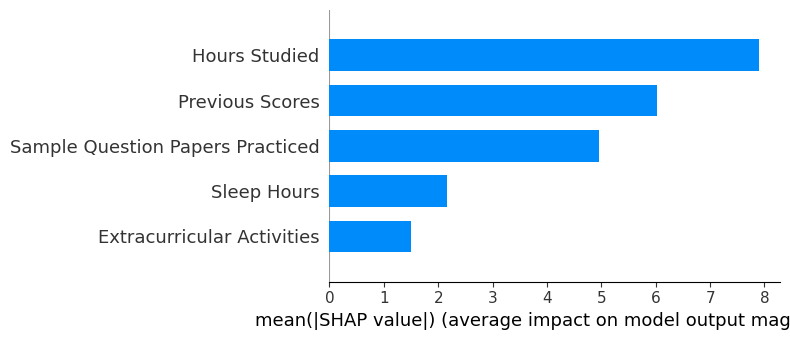

<Figure size 640x480 with 0 Axes>

In [15]:
import shap

# Create explainer
explainer = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test)

feature_names = list(X.columns)

# Summary plot - which features matter most
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")
plt.savefig("../plots/shap_summary.png")
plt.show()